In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test
import warnings, os
import os
os.chdir("/Users/Meralle/PyCharmMiscProject/T-ALL Analysis")

warnings.filterwarnings("ignore")
plt.rcParams.update({'figure.dpi': 150, 'font.size': 10,
                     'axes.titlesize': 11, 'figure.facecolor': 'white'})

output_dir = "polonen_replication_outputs"
os.makedirs(output_dir, exist_ok=True)

supp_file = "polonen.xlsx"

In [9]:
print("="*70)
print("STEP 0: LOAD SUPPLEMENTARY DATA")
print("="*70)

xl = pd.ExcelFile(supp_file)

st4 = pd.read_excel(xl, sheet_name="ST4_UMAP_Coordinates")
st3 = pd.read_excel(xl, sheet_name="ST3_Sample_Annotations")
st1 = pd.read_excel(xl, sheet_name="ST1_Clinical_Data")
st37 = pd.read_excel(xl, sheet_name="ST37_Stats.Univariable.ETP")
st37 = st37[st37['Feature'].isin(['ETP', 'Near-ETP', 'Non-ETP'])].copy()

print(f' ST4 UMAP coordinates: {st4.shape[0]} samples')
print(f' ST3 Sample annotations: {st3.shape[0]} samples')
print (f' ST1 Clinical data: {st1.shape[0]} samples')
print(f' ST37 Cox ETP results: loaded')

#merge on sample ID
df = st4.merge(
    st3[['sample', 'Reviewed.subtype', 'ETP_status']],
    left_on=['ID'], right_on='sample', how='left'
).merge(
    st1[['USI', 'OS', 'OS.status', 'EFS', 'EFS.status', 'DFS', 'DFS.status']],
    left_on=['ID'], right_on=['USI'], how='left'
)

for col in ['OS', 'OS.status', 'EFS', 'EFS.status', 'DFS', 'DFS.status']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'\n Merged: {df.shape[0]} patients x {df.shape[1]} columns')
print(f'\n ETP status:')
print(df['ETP_status'].value_counts(dropna=False).to_string())
print(f'\n Genomic subtypes:')
print(df['Reviewed.subtype'].value_counts().to_string())

STEP 0: LOAD SUPPLEMENTARY DATA
 ST4 UMAP coordinates: 1335 samples
 ST3 Sample annotations: 1335 samples
 ST1 Clinical data: 1335 samples
 ST37 Cox ETP results: loaded

 Merged: 1335 patients x 14 columns

 ETP status:
ETP_status
Non-ETP     863
NaN         194
Near-ETP    168
ETP         110

 Genomic subtypes:
Reviewed.subtype
TAL1 DP-like    300
ETP-like        240
TAL1 αβ-like    223
TLX3            220
NKX2-1           77
TLX1             74
TME-enriched     42
KMT2A            39
MLLT10           32
HOXA9 TCR        22
BCL11B           18
SPI1             11
LMO2 γδ-like     10
STAG2/LMO2        8
NKX2-5            8
NUP98             6
NUP214            5


STEP 1: FIGURE 1a REPLICATION


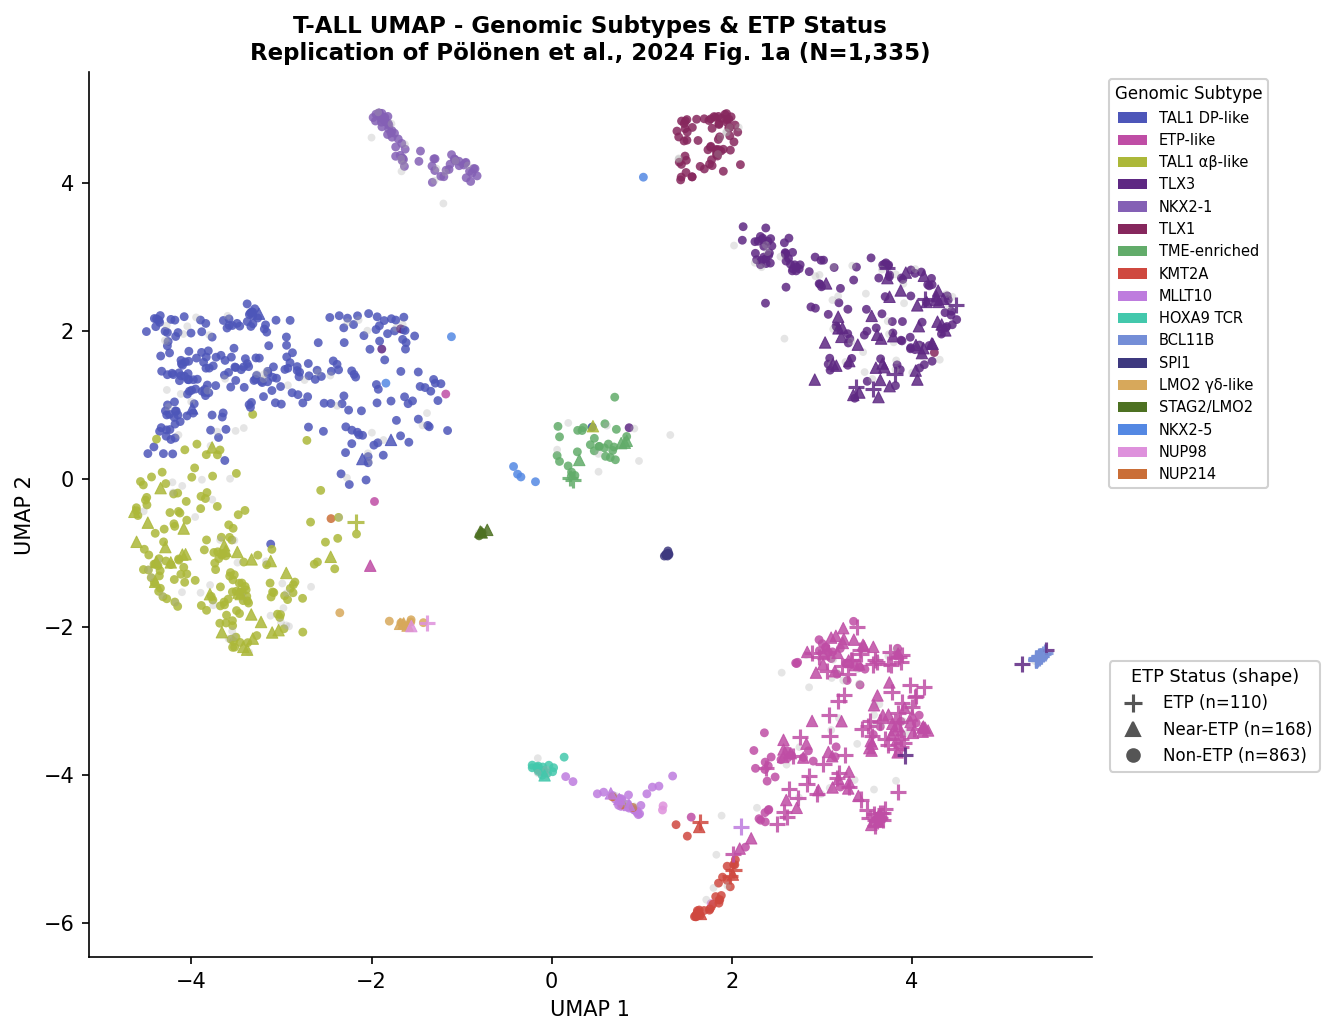

 Saved → polonen_replication_outputs/01_umap_figure1a_replication.png


In [14]:
print("="*70)
print("STEP 1: FIGURE 1a REPLICATION")
print("="*70)

etp_markers = {
    'ETP': {'marker': '+', 'size': 60, '1w': 1.5},
    'Near-ETP': {'marker': '^', 'size': 30, '1w': 0.5},
    'Non-ETP': {'marker': 'o', 'size': 18, '1w': 0},
    'Unknown': {'marker': 'o', 'size': 14, '1w': 0},
}

fig, ax = plt.subplots(figsize=(9, 7))

for etp_val, style in etp_markers.items():
    if etp_val == 'Unknown':
        mask = df['ETP_status'].isna()
        color_vals = ["#aaaaaa"] * mask.sum()
        alpha = 0.3
    else: 
        mask = df['ETP_status'] == etp_val
        color_vals = df.loc[mask, 'color'].tolist()
        alpha = 0.85

    subset = df[mask]
    if len(subset) == 0:
        continue

    ax.scatter(
        subset['x'], subset['y'],
        c=color_vals,
        marker=style['marker'],
        s=style['size'], 
        linewidths=style['1w'],
        alpha=alpha,
        edgecolors='none' if style['1w'] == 0 else color_vals,
        zorder=3 if etp_val == 'ETP' else (2 if etp_val == 'Near-ETP' else 1),
    )

#subtype colour legend
subtype_colors = df.dropna(subset=['Reviewed.subtype']).groupby('Reviewed.subtype')['color'].first()
subtype_order = df['Reviewed.subtype'].value_counts().index.tolist()
color_patches = [
    mpatches.Patch(facecolor=subtype_colors[s], label=s)
    for s in subtype_order if s in subtype_colors.index
]
legend_subtypes = ax.legend(
    handles=color_patches, title='Genomic Subtype',
    bbox_to_anchor=(1.01, 1), loc='upper left',
    fontsize=7, title_fontsize=8, framealpha=0.9, edgecolor = '#cccccc'
)

#ETP shape legend
shape_handles = [
    mlines.Line2D([], [], color='#555555', marker='+', markersize=9,
                  linewidth=0, markeredgewidth=1.5,
                  label=f'ETP (n={(df["ETP_status"]=="ETP").sum()})'),
    mlines.Line2D([], [], color='#555555', marker='^', markersize=7,
                  linewidth=0,
                  label=f'Near-ETP (n={(df["ETP_status"]=="Near-ETP").sum()})'),
    mlines.Line2D([], [], color='#555555', marker='o', markersize=6,
                  linewidth=0,
                  label=f'Non-ETP (n={(df["ETP_status"]=="Non-ETP").sum()})'),
]
ax.legend(
    handles=shape_handles, title="ETP Status (shape)",
    bbox_to_anchor=(1.01, 0.2), loc="lower left",
    fontsize=8, title_fontsize=8.5, framealpha=0.9, edgecolor="#cccccc"
)
ax.add_artist(legend_subtypes)

ax.set_xlabel("UMAP 1", fontsize=10)
ax.set_ylabel("UMAP 2", fontsize=10)
ax.set_title(
    "T-ALL UMAP - Genomic Subtypes & ETP Status\n"
    "Replication of Pölönen et al., 2024 Fig. 1a (N=1,335)",
    fontsize=11, fontweight='bold'
)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{output_dir}/01_umap_figure1a_replication.png', bbox_inches='tight', dpi=200)
plt.show()
print(f' Saved → {output_dir}/01_umap_figure1a_replication.png')

STEP 2: UMAP COLOURED BY ETP STATUS ONLY


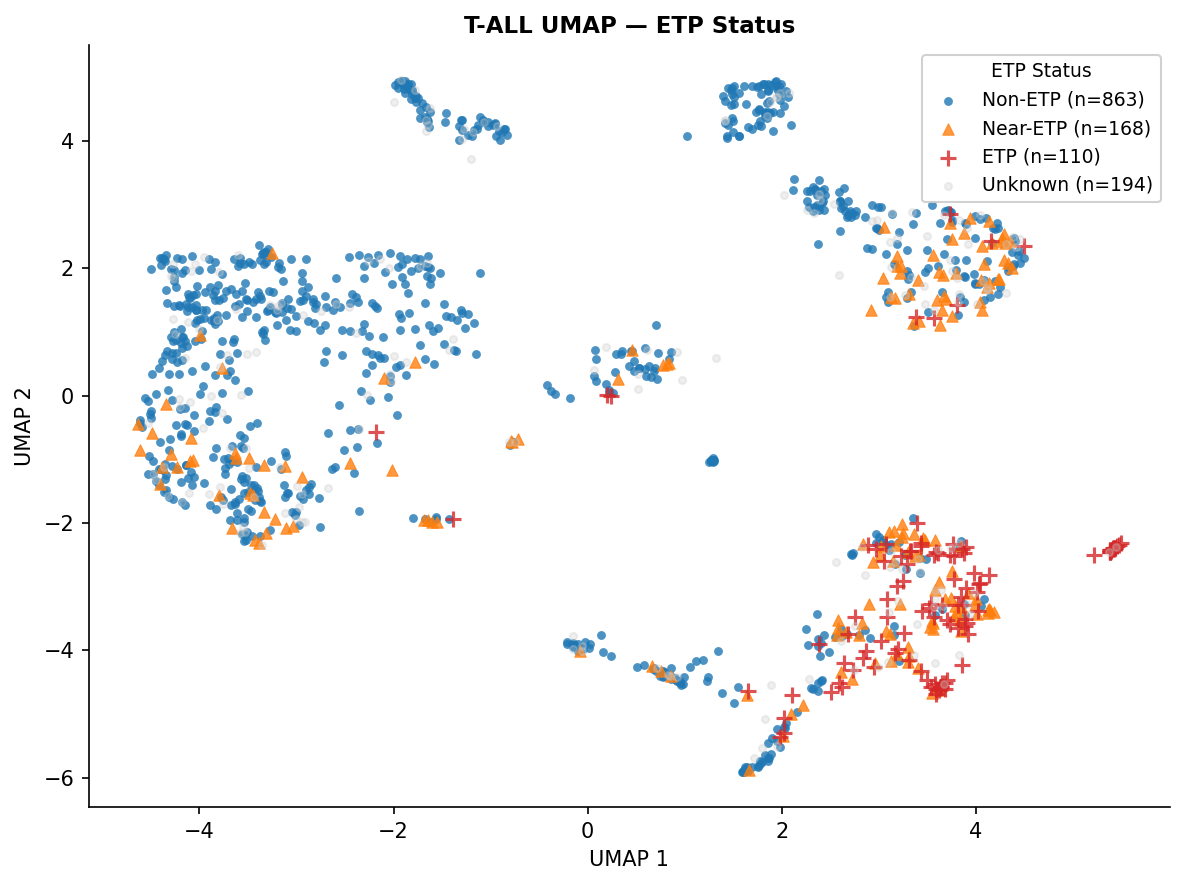

  Saved → polonen_replication_outputs/02_umap_etp_status.png


In [15]:
print("="*70)
print("STEP 2: UMAP COLOURED BY ETP STATUS ONLY")
print("="*70)

etp_colors = {'ETP': '#d62728', 'Near-ETP': '#ff7f0e', 'Non-ETP': '#1f77b4'}

fig, ax = plt.subplots(figsize=(8, 6))

for etp_val in ['Non-ETP', 'Near-ETP', 'ETP']: 
    style = etp_markers[etp_val]
    mask = df['ETP_status'] == etp_val
    subset = df[mask]
    ax.scatter(
        subset['x'], subset['y'],
        c=etp_colors[etp_val], 
        marker=style['marker'], 
        s=style['size'], 
        linewidths=style['1w'],
        alpha=0.8,
        label=f'{etp_val} (n={mask.sum()})'
    )

mask_na = df['ETP_status'].isna()
ax.scatter(df.loc[mask_na, 'x'], df.loc[mask_na, 'y'],
           c="#cccccc", s=12, alpha=0.3, label=f'Unknown (n={mask_na.sum()})')

ax.legend(fontsize=9, framealpha=0.9, title='ETP Status', title_fontsize=9)
ax.set_xlabel('UMAP 1', fontsize=10)
ax.set_ylabel('UMAP 2', fontsize=10)
ax.set_title('T-ALL UMAP — ETP Status', fontsize=11, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{output_dir}/02_umap_etp_status.png', bbox_inches='tight', dpi=200)
plt.show()
print(f'  Saved → {output_dir}/02_umap_etp_status.png')

In [19]:
print("="*70)
print("STEP 3: COX REGRESSION - ETP STATUS VS SURVIVAL")
print("="*70)

df['is_ETP'] = (df['ETP_status'] == 'ETP').astype(int)
df['is_NearETP'] = (df['ETP_status'] == 'Near-ETP').astype(int)

endpoints = [
    ('OS', 'OS.status', 'Overall Survival (OS)'),
    ('EFS', 'EFS.status', 'Event-Free Survival (EFS)'),
    ('DFS', 'DFS.status', 'Disease-Free Survival (DFS)')
]

cox_results = []

for dur, evt, label in endpoints:
    subset = df[['is_ETP', 'is_NearETP', dur, evt]].dropna()
    n = len(subset)
    print(f'\n {label} (n={n})')

    for group, col in [('ETP vs Non-ETP', 'is_ETP'),
                       ('Near-ETP vs Non-ETP', 'is_NearETP')]:
        try:
            cph = CoxPHFitter(penalizer=0.0)
            cph.fit(subset[[col, dur, evt]], duration_col=dur, event_col=evt)
            s = cph.summary
            hr = s.loc[col, 'exp(coef)']
            lower = s.loc[col, 'exp(coef) lower 95%']
            upper = s.loc[col, 'exp(coef) upper 95%']
            p = s.loc[col, 'p']
            print(f' {group}: HR={hr:.3f} ({lower:.3f}-{upper:.3f}), p={p:.4f}')
            cox_results.append({
                'Endpoint': label, 'Comparison': group, 'N': n,
                'HR': round(hr, 3), 'CI_lower': round(lower,3),
                'CI_upper': round(upper, 3), 'p_value': round(p, 4),
                'significant': p < 0.05,
            })
        except Exception as e:
            print(f' {group}: failed - {e}')

cox_df = pd.DataFrame(cox_results)
print('\n Summary:')
print(cox_df.to_string(index=False))

print('\n Paper ST37 results (for comparison):')
print(st37[['Feature', 'OS.HR', 'OS.P', 'EFS.HR', 'EFS.P', 'DFS.HR', 'DFS.P']].to_string(index=False))

STEP 3: COX REGRESSION - ETP STATUS VS SURVIVAL

 Overall Survival (OS) (n=1335)
 ETP vs Non-ETP: HR=1.694 (1.033-2.779), p=0.0367
 Near-ETP vs Non-ETP: HR=0.644 (0.357-1.164), p=0.1453

 Event-Free Survival (EFS) (n=1335)
 ETP vs Non-ETP: HR=1.423 (0.931-2.175), p=0.1027
 Near-ETP vs Non-ETP: HR=1.003 (0.671-1.501), p=0.9875

 Disease-Free Survival (DFS) (n=1015)
 ETP vs Non-ETP: HR=1.027 (0.555-1.901), p=0.9323
 Near-ETP vs Non-ETP: HR=0.763 (0.422-1.378), p=0.3694

 Summary:
                   Endpoint          Comparison    N    HR  CI_lower  CI_upper  p_value  significant
      Overall Survival (OS)      ETP vs Non-ETP 1335 1.694     1.033     2.779   0.0367         True
      Overall Survival (OS) Near-ETP vs Non-ETP 1335 0.644     0.357     1.164   0.1453        False
  Event-Free Survival (EFS)      ETP vs Non-ETP 1335 1.423     0.931     2.175   0.1027        False
  Event-Free Survival (EFS) Near-ETP vs Non-ETP 1335 1.003     0.671     1.501   0.9875        False
Disease-Free

STEP 4: FOREST PLOT


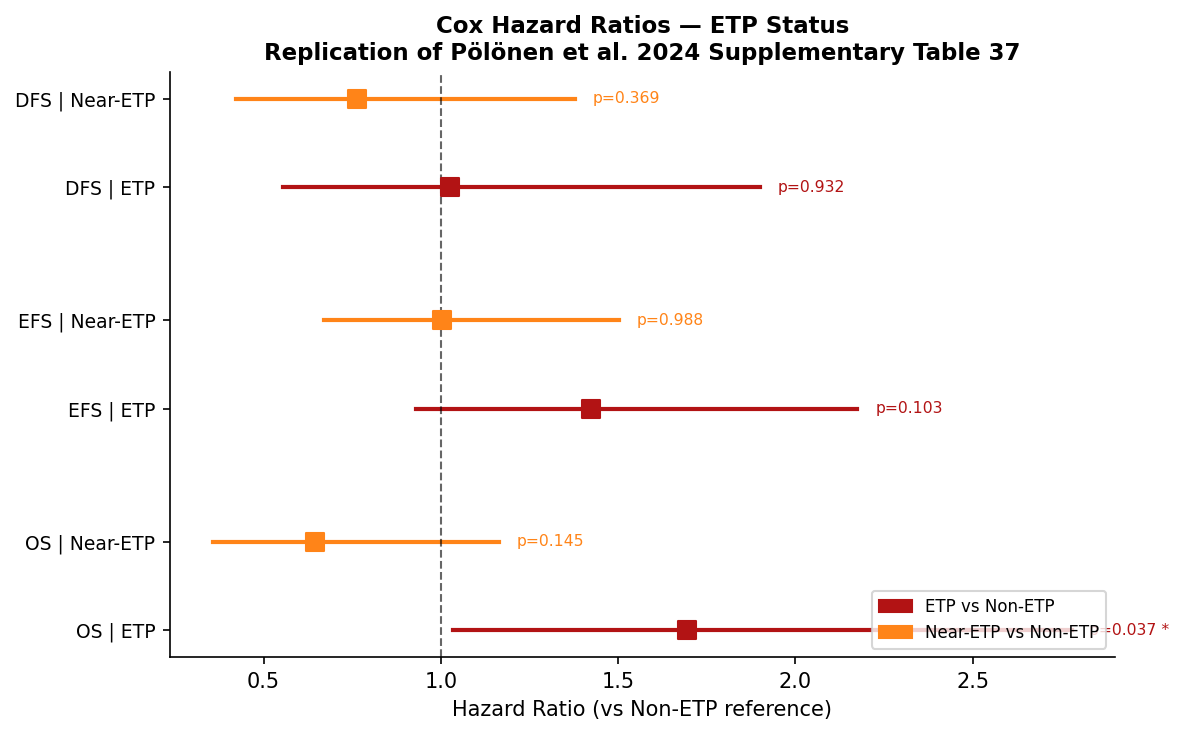

  Saved → polonen_replication_outputs/03_forest_plot_etp_cox.png


In [24]:
print("="*70)
print("STEP 4: FOREST PLOT")
print("="*70)

endpoint_labels = {
    'Overall Survival (OS)': 'OS',
    'Event-Free Survival (EFS)': 'EFS',
    'Disease-Free Survival (DFS)': 'DFS',
}
group_colors = {
    'ETP vs Non-ETP': '#b21314',
    'Near-ETP vs Non-ETP': '#ff8418',
}

fig, ax = plt.subplots(figsize=(8, 5))
y, y_positions, y_labels = 0, [], []

for endpoint in ['Overall Survival (OS)', 'Event-Free Survival (EFS)', 
                 'Disease-Free Survival (DFS)']:
    for _, row in cox_df[cox_df['Endpoint'] == endpoint].iterrows():
        color = group_colors[row['Comparison']]
        marker = 's' if 'ETP vs' in row['Comparison'] else 'D'
        ax.plot([row['CI_lower'], row['CI_upper']], [y, y], color=color, lw=2, zorder=2)
        ax.scatter(row['HR'], y, color=color, s=80, zorder=3, marker=marker)
        p_label = f'p={row["p_value"]:.3f}' + (' *' if row['significant'] else '')
        ax.text(row['CI_upper'] + 0.05, y, p_label, va='center', fontsize=7.5, color=color)
        y_labels.append(f'{endpoint_labels[endpoint]} | {row["Comparison"].replace(" vs Non-ETP", "")}')
        y_positions.append(y)
        y += 1
    y += 0.5

ax.axvline(1.0, color='black', linestyle='--', lw=1, alpha=0.6)
ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels, fontsize=9)
ax.set_xlabel('Hazard Ratio (vs Non-ETP reference)', fontsize=10)
ax.set_title(
    'Cox Hazard Ratios — ETP Status\n'
    'Replication of Pölönen et al. 2024 Supplementary Table 37',
    fontsize=11, fontweight='bold'
)
ax.legend(
    handles=[mpatches.Patch(color=c, label=l) for l, c in group_colors.items()],
    fontsize=8, loc='lower right'
)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{output_dir}/03_forest_plot_etp_cox.png', bbox_inches='tight', dpi=200)
plt.show()
print(f'  Saved → {output_dir}/03_forest_plot_etp_cox.png')

STEP 5: KAPLAN-MEIER CURVES BY ETP STATUS
  Overall Survival (OS): log-rank p=0.5749
  Event-Free Survival (EFS): log-rank p=0.5750
  Disease-Free Survival (DFS): log-rank p=0.6583


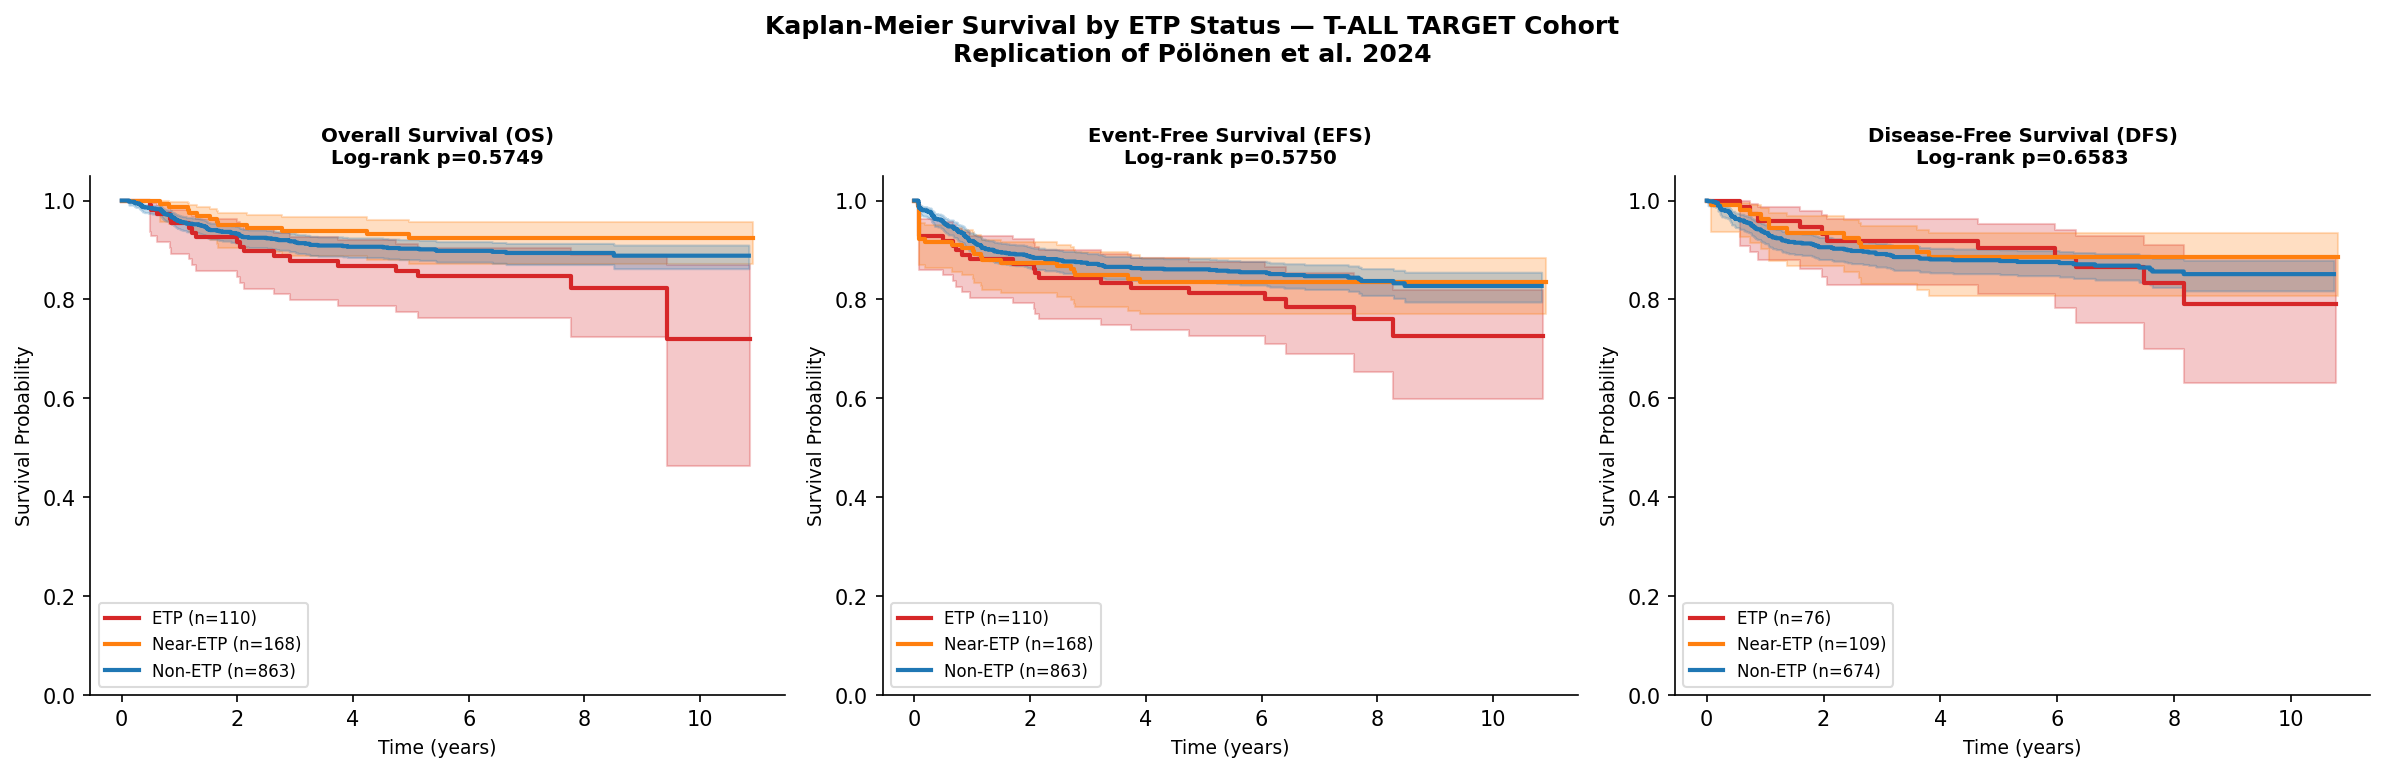

  Saved → polonen_replication_outputs/04_km_curves_etp.png


In [25]:
print("="*70)
print("STEP 5: KAPLAN-MEIER CURVES BY ETP STATUS")
print("="*70)

etp_km_colors = {'ETP':'#d62728', 'Near-ETP': '#ff7f0e', 'Non-ETP': '#1f77b4'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
 
for ax, (dur, evt, label) in zip(axes, endpoints):
    subset = df[['ETP_status', dur, evt]].dropna()
    kmf    = KaplanMeierFitter()

    for etp_val, color in etp_km_colors.items():
        mask = subset['ETP_status'] == etp_val
        n    = mask.sum()
        if n < 5:
            continue
        kmf.fit(
            subset.loc[mask, dur] / 365.25,
            event_observed=subset.loc[mask, evt],
            label=f'{etp_val} (n={n})'
        )
        kmf.plot_survival_function(ax=ax, ci_show=True, color=color, linewidth=2)
    
    mlr = multivariate_logrank_test(subset[dur], subset['ETP_status'], event_col=subset[evt])
    p   = mlr.p_value
    sig = ' ✓' if p < 0.05 else ''
    print(f'  {label}: log-rank p={p:.4f}{sig}')

    ax.set_title(f'{label}\nLog-rank p={p:.4f}{sig}', fontsize=9.5, fontweight='bold')
    ax.set_xlabel('Time (years)', fontsize=9)
    ax.set_ylabel('Survival Probability', fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8, framealpha=0.7)
    ax.spines[['top', 'right']].set_visible(False)
 
plt.suptitle(
    'Kaplan-Meier Survival by ETP Status — T-ALL TARGET Cohort\n'
    'Replication of Pölönen et al. 2024',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(f'{output_dir}/04_km_curves_etp.png', bbox_inches='tight', dpi=200)
plt.show()
print(f'  Saved → {output_dir}/04_km_curves_etp.png')
 
 

STEP 6: ETP DISTRIBUTION ACROSS SUBTYPES
ETP_status        ETP  Near-ETP  Non-ETP
Reviewed.subtype                        
TAL1 DP-like        0         4      258
ETP-like           78        69       57
TAL1 αβ-like        1        31      154
TLX3                9        46      127
NKX2-1              0         0       64
TLX1                0         0       66
TME-enriched        2         4       29
KMT2A               3         3       29
MLLT10              1         3       25
HOXA9 TCR           0         1       18
BCL11B             15         0        1
SPI1                0         0       11
LMO2 γδ-like        0         3        7
STAG2/LMO2          0         3        3
NKX2-5              0         0        7
NUP98               1         1        3
NUP214              0         0        4


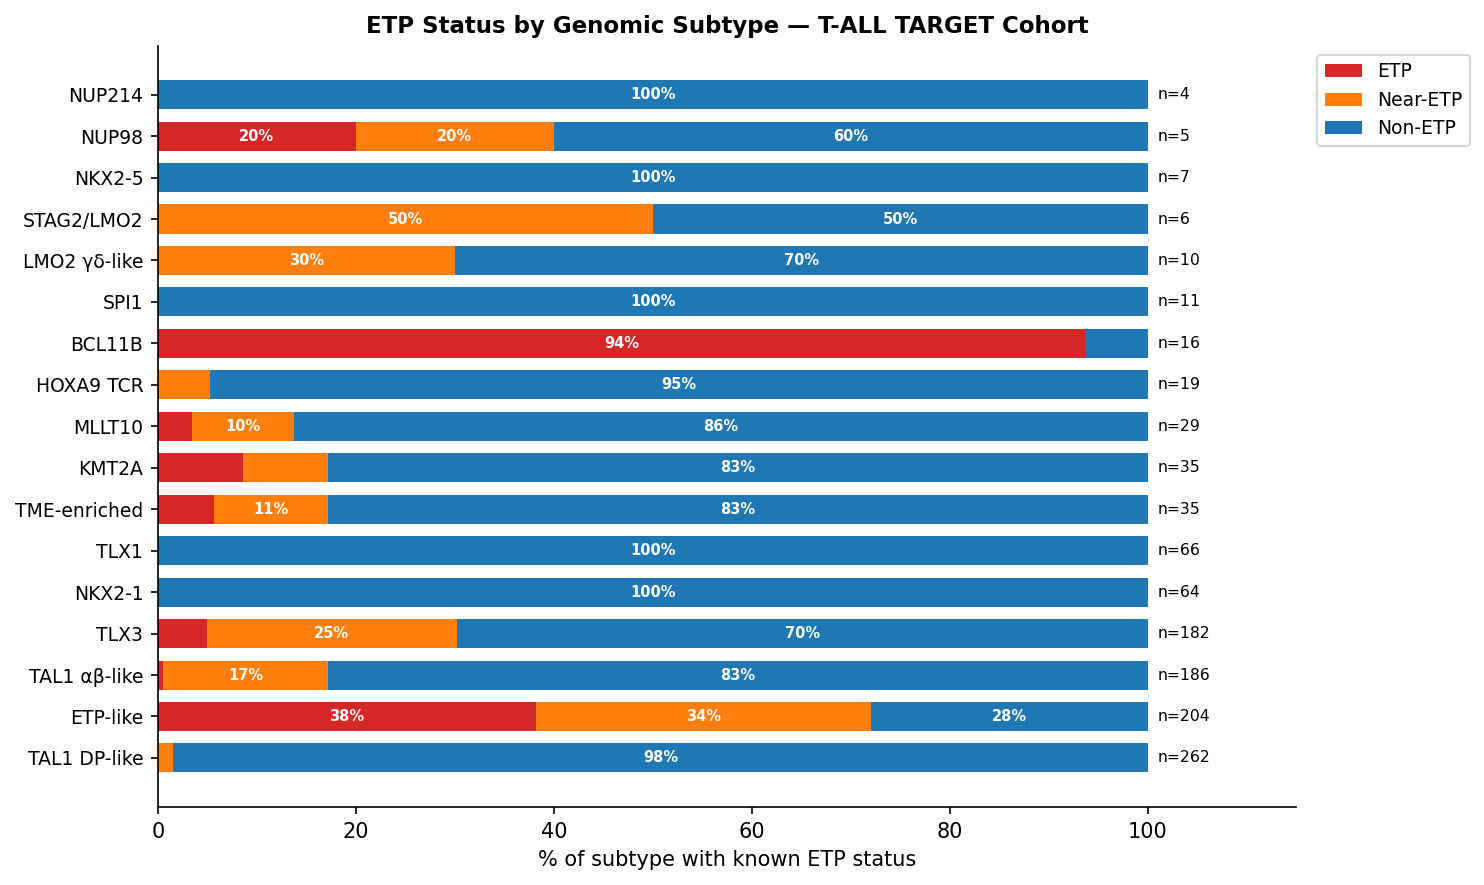

  Saved → polonen_replication_outputs/05_etp_by_subtype.png


In [26]:
print("="*70)
print("STEP 6: ETP DISTRIBUTION ACROSS SUBTYPES")
print("="*70)

ct     = pd.crosstab(df['Reviewed.subtype'], df['ETP_status']).fillna(0)
ct     = ct.loc[df['Reviewed.subtype'].value_counts().index.tolist()]
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

print(ct.to_string())
 
etp_col_order = [c for c in ['ETP', 'Near-ETP', 'Non-ETP'] if c in ct_pct.columns]
bar_colors    = {'ETP': '#d62728', 'Near-ETP': '#ff7f0e', 'Non-ETP': '#1f77b4'}

ig, ax = plt.subplots(figsize=(10, 6))
bottom  = np.zeros(len(ct_pct))
 
for etp in etp_col_order:
    vals = ct_pct[etp].values
    ax.barh(range(len(ct_pct)), vals, left=bottom,
            color=bar_colors[etp], label=etp, height=0.7)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 10:
            ax.text(b + v / 2, i, f'{v:.0f}%',
                    ha='center', va='center', fontsize=7, color='white', fontweight='bold')
    bottom += vals

for i, subtype in enumerate(ct.index):
    ax.text(101, i, f'n={int(ct.loc[subtype, etp_col_order].sum())}', va='center', fontsize=7.5)
 
ax.set_yticks(range(len(ct_pct)))
ax.set_yticklabels(ct_pct.index, fontsize=9)
ax.set_xlabel('% of subtype with known ETP status', fontsize=10)
ax.set_xlim(0, 115)
ax.set_title(
    'ETP Status by Genomic Subtype — T-ALL TARGET Cohort',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{output_dir}/05_etp_by_subtype.png', bbox_inches='tight', dpi=200)
plt.show()
print(f'  Saved → {output_dir}/05_etp_by_subtype.png')

In [28]:
print("="*70)
print("STEP 7: EXPORT")
print("="*70)

export_cols = ['ID', 'x', 'y', 'color', 'Reviewed.subtype', 'ETP_status',
               'OS', 'OS.status', 'EFS', 'EFS.status', 'DFS', 'DFS.status']
df[export_cols].to_csv(f'{output_dir}/06_merged_umap_clinical.csv', index=False)
cox_df.to_csv(f'{output_dir}/07_cox_etp_results.csv', index=False)
 
print(f'  Merged data  → {output_dir}/06_merged_umap_clinical.csv')
print(f'  Cox results  → {output_dir}/07_cox_etp_results.csv')
print(f'\n  All outputs in: {output_dir}/')
for f in sorted(os.listdir(output_dir)):
    print(f'    {f}')

STEP 7: EXPORT
  Merged data  → polonen_replication_outputs/06_merged_umap_clinical.csv
  Cox results  → polonen_replication_outputs/07_cox_etp_results.csv

  All outputs in: polonen_replication_outputs/
    .ipynb_checkpoints
    01_umap_figure1a_replication.png
    02_umap_etp_status.png
    03_forest_plot_etp_cox.png
    04_km_curves_etp.png
    05_etp_by_subtype.png
    06_merged_umap_clinical.csv
    07_cox_etp_results.csv
